<a href="https://colab.research.google.com/github/tadesseabera95-ship-it/Phishing-Detection-ML/blob/main/EmailPhishing_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score,confusion_matrix, average_precision_score,roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
import warnings
warnings.filterwarnings('ignore')



#Dataset loading and Analysis

In [4]:
df=pd.read_csv('/email_phishing_data.csv')

In [6]:
df.tail()

,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
524841,782,327,301,2,2,2,52,1,0
524842,36,30,11,0,0,0,4,0,1
524843,61,46,11,0,0,0,3,0,0
524844,213,136,89,0,0,0,18,0,0
524845,26,24,3,0,0,0,2,0,0


In [7]:
df.info() # column and rows of the dataset information

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 524846 entries, 0 to 524845
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   num_words            524846 non-null  int64
 1   num_unique_words     524846 non-null  int64
 2   num_stopwords        524846 non-null  int64
 3   num_links            524846 non-null  int64
 4   num_unique_domains   524846 non-null  int64
 5   num_email_addresses  524846 non-null  int64
 6   num_spelling_errors  524846 non-null  int64
 7   num_urgent_keywords  524846 non-null  int64
 8   label                524846 non-null  int64
dtypes: int64(9)
memory usage: 36.0 MB


The number of safe and phishing email samples on the dataset

In [8]:
df['label'].value_counts()

,count
label,
0,517897
1,6949


Checking if the dataset have missing values

In [9]:
df.isnull(  ).sum()

,0
num_words,0
num_unique_words,0
num_stopwords,0
num_links,0
num_unique_domains,0
num_email_addresses,0
num_spelling_errors,0
num_urgent_keywords,0
label,0


## Descriptive Statistics

In [11]:
df.describe()

,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
count,5.248460e+05,524846.000000,524846.000000,524846.000000,524846.000000,524846.000000,524846.000000,524846.000000,524846.000000
mean,2.762280e+02,123.012167,80.045465,0.895588,0.347767,2.114897,24.694731,0.245301,0.013240
std,3.335457e+03,201.626478,1023.330380,5.603001,1.774209,13.592682,311.312358,0.559320,0.114301
min,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.700000e+01,38.000000,12.000000,0.000000,0.000000,0.000000,2.000000,0.000000,0.000000
50%,1.200000e+02,79.000000,34.000000,0.000000,0.000000,0.000000,8.000000,0.000000,0.000000
75%,2.690000e+02,145.000000,79.000000,0.000000,0.000000,1.000000,22.000000,0.000000,0.000000
max,2.339682e+06,51251.000000,720411.000000,824.000000,524.000000,1150.000000,190104.000000,7.000000,1.000000


## Visualizing the Label Distribution

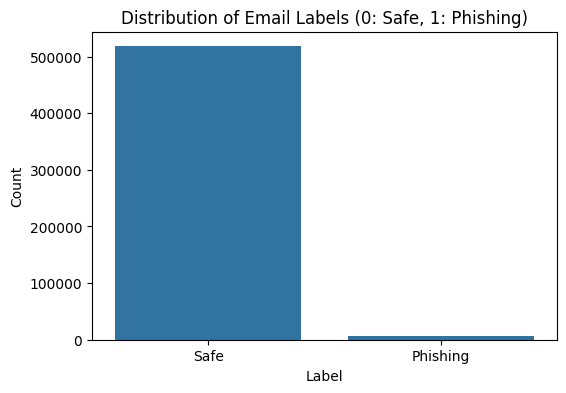

In [14]:
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df)
plt.title('Distribution of Email Labels (0: Safe, 1: Phishing)')
plt.xlabel('Label')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Safe', 'Phishing'])
plt.show()

## Visualizing email label Distributions on pie plot

---



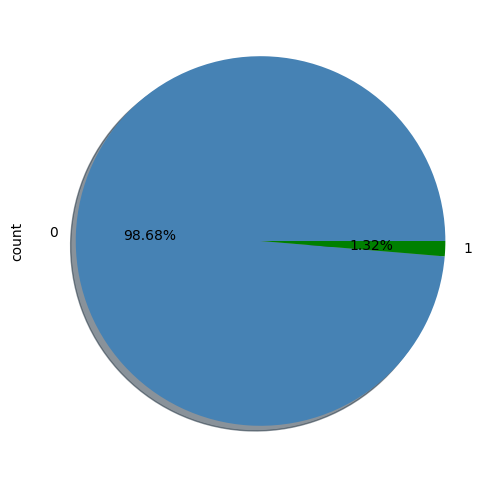

In [17]:
df['label'].value_counts().plot(kind='pie', autopct='%.2f%%', shadow=True, figsize=(11,6), colors=['steelblue', 'green'])
plt.show()

## Data Preparation: Handling Imbalance and Splitting Data

Given the significant class imbalance observed in the 'label' column (as seen in the pie chart above), it's crucial to address this during data preparation to prevent the model from being biased towards the majority class. We will also define our features (X) and target (y) and then split the data into training and testing sets.

In [18]:
# Define features (X) and target (y)
X = df.drop('label', axis=1)
y = df['label']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")# The labels

Features shape: (524846, 8)
Target shape: (524846,)


### Splitting the data into Training and Testing Sets

We will split the data into 80% for training and 20% for testing. It's important to use `stratify=y` to ensure that both the training and testing sets have a similar proportion of safe and phishing emails, especially given the imbalance.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nClass distribution in original data (counts):")
print(y.value_counts())
print("\nClass distribution in training set (counts):")
print(y_train.value_counts())
print("\nClass distribution in testing set (counts):")
print(y_test.value_counts())

X_train shape: (419876, 8)
X_test shape: (104970, 8)
y_train shape: (419876,)
y_test shape: (104970,)

Class distribution in original data (counts):
label
0    517897
1      6949
Name: count, dtype: int64

Class distribution in training set (counts):
label
0    414317
1      5559
Name: count, dtype: int64

Class distribution in testing set (counts):
label
0    103580
1      1390
Name: count, dtype: int64


### Feature Scaling

Next, we will scale the numerical features using `StandardScaler`. This helps ensure that features with larger values do not dominate the learning process. It's important to fit the scaler only on the training data to prevent data leakage.

In [20]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Scaled training data head:")
display(X_train_scaled_df.head())
print("Scaled testing data head:")
display(X_test_scaled_df.head())

Scaled training data head:


,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords
0,-0.057177,-0.312315,-0.061161,-0.160012,-0.193912,-0.154000,-0.047847,-0.437819
1,-0.070940,-0.531343,-0.066432,0.019149,0.362772,-0.154000,-0.075248,-0.437819
2,-0.009142,0.179282,-0.004935,-0.160012,-0.193912,0.064345,-0.023491,-0.437819
3,0.014066,0.203619,0.036356,-0.160012,-0.193912,-0.154000,-0.050892,-0.437819
4,-0.028032,-0.039746,-0.040076,-0.160012,-0.193912,-0.081218,-0.026535,-0.437819


Scaled testing data head:


,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords
0,-0.069051,-0.511874,-0.070825,-0.160012,-0.193912,-0.154000,-0.072204,-0.437819
1,-0.055288,-0.317182,-0.049740,0.198311,0.919455,-0.154000,-0.056981,-0.437819
2,-0.045573,-0.210102,-0.042712,-0.160012,-0.193912,-0.154000,-0.060025,-0.437819
3,-0.028572,-0.107888,-0.024263,-0.160012,-0.193912,-0.154000,-0.053936,-0.437819
4,0.004081,0.140344,-0.000542,0.019149,0.362772,0.209907,0.043490,-0.437819


## Model Definition and Training

### 1. RandomForestClassifier

Random Forest Classifier Evaluation:
Accuracy: 0.9894
Precision: 0.8167
Recall: 0.2597
F1 Score: 0.3941
ROC AUC Score: 0.8664


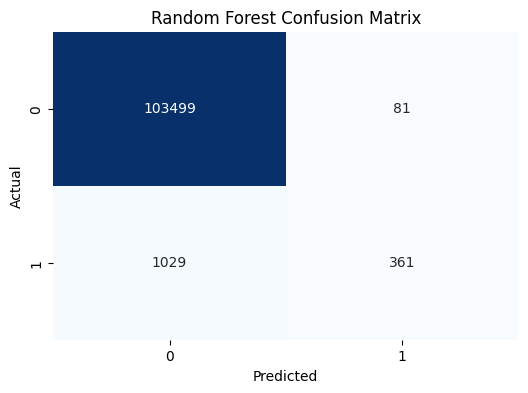

In [22]:
# Initialize and train the RandomForestClassifier
rf_classifier = RandomForestClassifier(random_state=42, n_jobs=-1) # n_jobs=-1 uses all available processors
rf_classifier.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_rf = rf_classifier.predict(X_test_scaled)
y_proba_rf = rf_classifier.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
print("Random Forest Classifier Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_rf):.4f}")

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 2. XGBoost Classifier

XGBoost Classifier Evaluation:
Accuracy: 0.9882
Precision: 0.8025
Recall: 0.1403
F1 Score: 0.2388
ROC AUC Score: 0.8827


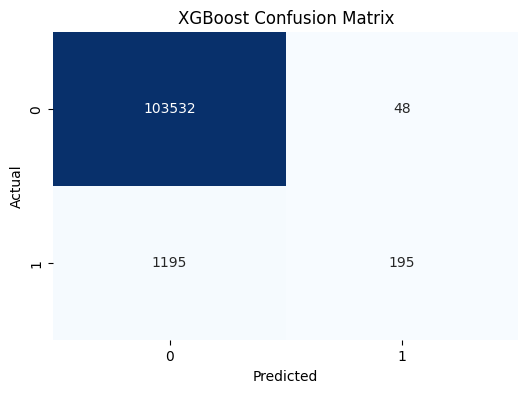

In [23]:
# Initialize and train the XGBoost Classifier
xgb_classifier = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', n_jobs=-1)
xgb_classifier.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_xgb = xgb_classifier.predict(X_test_scaled)
y_proba_xgb = xgb_classifier.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
print("XGBoost Classifier Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_xgb):.4f}")

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 3. LightGBM Classifier

[LightGBM] [Info] Number of positive: 5559, number of negative: 414317
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014976 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1379
[LightGBM] [Info] Number of data points in the train set: 419876, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.013240 -> initscore=-4.311213
[LightGBM] [Info] Start training from score -4.311213
LightGBM Classifier Evaluation:
Accuracy: 0.9877
Precision: 0.7004
Recall: 0.1194
F1 Score: 0.2041
ROC AUC Score: 0.8771


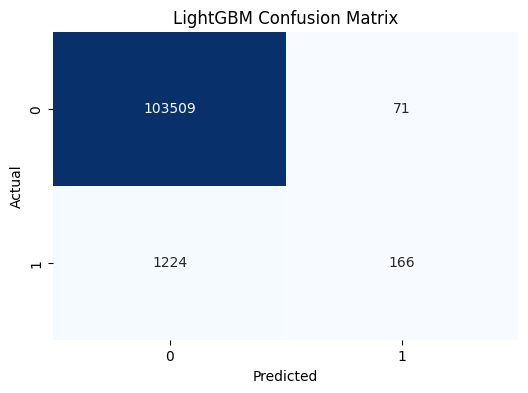

In [24]:
# Initialize and train the LightGBM Classifier
lgbm_classifier = lgb.LGBMClassifier(random_state=42, n_jobs=-1)
lgbm_classifier.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred_lgbm = lgbm_classifier.predict(X_test_scaled)
y_proba_lgbm = lgbm_classifier.predict_proba(X_test_scaled)[:, 1]

# Evaluate the model
print("LightGBM Classifier Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lgbm):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lgbm):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lgbm):.4f}")
print(f"F1 Score: {f1_score(y_test, y_pred_lgbm):.4f}")
print(f"ROC AUC Score: {roc_auc_score(y_test, y_proba_lgbm):.4f}")

# Confusion Matrix
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('LightGBM Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Model Performance Comparison

In [25]:
model_names = ['Random Forest', 'XGBoost', 'LightGBM']

accuracy = [accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_xgb), accuracy_score(y_test, y_pred_lgbm)]
precision = [precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_xgb), precision_score(y_test, y_pred_lgbm)]
recall = [recall_score(y_test, y_pred_rf), recall_score(y_test, y_pred_xgb), recall_score(y_test, y_pred_lgbm)]
f1 = [f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_xgb), f1_score(y_test, y_pred_lgbm)]
roc_auc = [roc_auc_score(y_test, y_proba_rf), roc_auc_score(y_test, y_proba_xgb), roc_auc_score(y_test, y_proba_lgbm)]

performance_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1 Score': f1,
    'ROC AUC Score': roc_auc
})

display(performance_df.round(4).sort_values(by='F1 Score', ascending=False))

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC Score
0,Random Forest,0.9894,0.8167,0.2597,0.3941,0.8664
1,XGBoost,0.9882,0.8025,0.1403,0.2388,0.8827
2,LightGBM,0.9877,0.7004,0.1194,0.2041,0.8771
